# DNN — TensorFlow / Keras (CPU)

## Model: Deep Neural Network (Multi-Layer Perceptron)
- **Dataset**: UCI HAR — 7,352 train / 2,947 test, 561 sensor features
- **Task**: Classify 6 human activities (3 dynamic, 3 static)
- **Framework showcase**: Keras Callbacks — EarlyStopping + ReduceLROnPlateau + TensorBoard-ready history

## CPU Strategy
- TF 2.11+ dropped native Windows GPU support — all ops run on CPU
- Keras `Sequential` API for model building (high-level, production-oriented)
- Built-in `model.fit()` with validation_split, callbacks, and automatic history tracking
- No manual training loop needed — Keras handles epochs, batches, metrics internally

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tensorflow as tf
from tensorflow import keras

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_training_history)
from utils.metrics import evaluate_classifier
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
N_CLASSES = 6
BATCH_SIZE = 64
ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

# Reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Load preprocessed UCI HAR
X_train, X_test, y_train, y_test, meta = load_processed_data('dnn')

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} DNN")
print("=" * 60)
print(f"  Device: CPU (TF 2.11+ dropped native Windows GPU)")
print(f"  TF version: {tf.__version__}")
print(f"  Train: {X_train.shape} | Test: {X_test.shape}")
print(f"  Classes: {N_CLASSES} ({', '.join(ACTIVITY_NAMES)})")
print(f"  Label range: [{y_train.min()}, {y_train.max()}]")
print(f"  Dtype: {X_train.dtype}")

[1/8] Data loaded — TensorFlow DNN
  Device: CPU (TF 2.11+ dropped native Windows GPU)
  TF version: 2.20.0
  Train: (7352, 561) | Test: (2947, 561)
  Classes: 6 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
  Label range: [0, 5]
  Dtype: float32


In [2]:
# Step 2: Simple baseline — Keras Sequential API

"""
Keras handles training loop, batching, validation split, and history internally
This is the key TF advantage: model.fit() replaces 30+ lines of manual training code
"""

print("=" * 60)
print("[2/8] SIMPLE BASELINE DNN")
print("=" * 60)

baseline = keras.Sequential([
    keras.layers.Input(shape=(561,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(N_CLASSES, activation='softmax')
])

baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # integer labels, no one-hot needed
    metrics=['accuracy']
)

# model.fit() handles batching, validation split, and epoch logging
history_base = baseline.fit(
    X_train, y_train,
    epochs=200,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=15, restore_best_weights=True
        )
    ],
    verbose=0  # silent — we'll print summary ourselves
)

y_pred_base = baseline.predict(X_test, verbose=0).argmax(axis=1)
base_metrics = evaluate_classifier(y_test, y_pred_base)

n_epochs = len(history_base.history['loss'])
best_val_acc = max(history_base.history['val_accuracy'])

print(f"\n  Architecture: 561 → 128 → 6")
print(f"  Epochs: {n_epochs} (best val_acc: {best_val_acc:.4f})")
print(f"  Final train loss: {history_base.history['loss'][-1]:.4f}")
print(f"\n  Test Results:")
print(f"    Accuracy: {base_metrics['accuracy']:.4f}")
print(f"    Macro F1: {base_metrics['macro_f1']:.4f}")


[2/8] SIMPLE BASELINE DNN

  Architecture: 561 → 128 → 6
  Epochs: 30 (best val_acc: 0.9810)
  Final train loss: 0.0010

  Test Results:
    Accuracy: 0.9413
    Macro F1: 0.9414


[3/8] TRAINING HISTORY


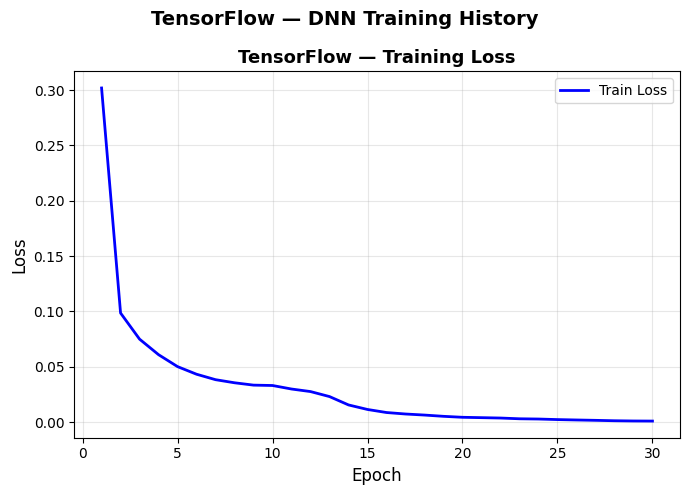

  Epochs: 30
  Loss: 0.3019 -> 0.0010
  Val acc: 0.9606 -> 0.9810


In [3]:
# Step 3: Visualize baseline training curves
# Keras history object automatically tracks loss + val_loss + accuracy + val_accuracy
print("=" * 60)
print("[3/8] TRAINING HISTORY")
print("=" * 60)

history = {
    'train_loss': history_base.history['loss'],
    'val_acc': history_base.history['val_accuracy']
}

plot_training_history(history, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_baseline.png')

print(f"  Epochs: {len(history_base.history['loss'])}")
print(f"  Loss: {history_base.history['loss'][0]:.4f} -> {history_base.history['loss'][-1]:.4f}")
print(f"  Val acc: {history_base.history['val_accuracy'][0]:.4f} -> {max(history_base.history['val_accuracy']):.4f}")

[4/8] SHOWCASE: KERAS CALLBACKS

  [1/2] Simple DNN (128-64)...
    Epochs: 33 | Acc: 0.9335 | F1: 0.9336

  [2/2] Regularized DNN (128-64, BN+Dropout+LR callbacks)...
    Epochs: 32 | Acc: 0.9376 | F1: 0.9376


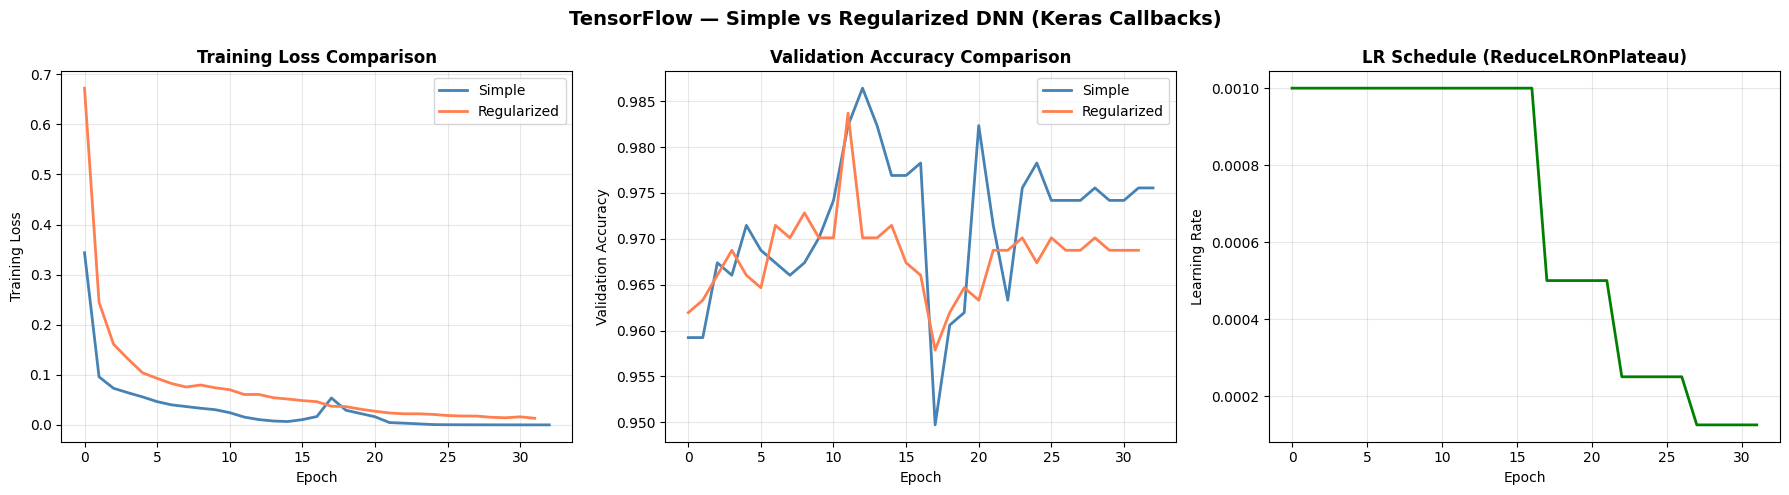


  Model                     Acc       F1   Epochs
  ----------------------------------------------
  Simple (128-64)        0.9335   0.9336       33
  Regularized (128-64)   0.9376   0.9376       32

  Keras callbacks vs PyTorch manual loop:
    PT: ~40 lines (train_regularized function with manual LR step)
    TF: 5 lines (2 callback objects + model.fit)


In [4]:
# Step 4: TF showcase — Keras Callbacks ecosystem

"""
Keras provides built-in callbacks that replace manual training loop logic:
  - EarlyStopping: monitors metric, stops + restores best weights
  - ReduceLROnPlateau: cuts LR when metric plateaus (same as PT, but zero code)
  - ModelCheckpoint, TensorBoard, CSVLogger also available (not used here)
In PyTorch, we wrote 40 lines for train_regularized(). Keras does it in callbacks.
"""

print("=" * 60)
print("[4/8] SHOWCASE: KERAS CALLBACKS")
print("=" * 60)

# Build regularized model (BatchNorm + Dropout — same as PT)
def build_model(hidden_sizes, dropout=0.3):
    """
    Build a Keras Sequential DNN with BatchNorm + Dropout.

    Args:
        hidden_sizes: Tuple of hidden layer sizes.
        dropout: Dropout rate after each hidden layer.

    Returns:
        Compiled Keras model.
    """
    layers = [keras.layers.Input(shape=(561,))]
    for h in hidden_sizes:
        layers.append(keras.layers.Dense(h))
        layers.append(keras.layers.BatchNormalization())
        layers.append(keras.layers.ReLU())
        layers.append(keras.layers.Dropout(dropout))
    layers.append(keras.layers.Dense(N_CLASSES, activation='softmax'))

    model = keras.Sequential(layers)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Compare: Simple vs Regularized on same (128, 64) architecture
print("\n  [1/2] Simple DNN (128-64)...")
tf.random.set_seed(RANDOM_STATE)
simple = keras.Sequential([
    keras.layers.Input(shape=(561,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(N_CLASSES, activation='softmax')
])
simple.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

h_simple = simple.fit(
    X_train, y_train, epochs=200, batch_size=BATCH_SIZE, validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20,
                                             restore_best_weights=True)],
    verbose=0
)
y_pred_simple = simple.predict(X_test, verbose=0).argmax(axis=1)
m_simple = evaluate_classifier(y_test, y_pred_simple)
print(f"    Epochs: {len(h_simple.history['loss'])} | Acc: {m_simple['accuracy']:.4f} | F1: {m_simple['macro_f1']:.4f}")

print("\n  [2/2] Regularized DNN (128-64, BN+Dropout+LR callbacks)...")
tf.random.set_seed(RANDOM_STATE)
reg_model = build_model((128, 64), dropout=0.3)

# The showcase: callbacks replace manual training loop logic
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=5
    )
]

h_reg = reg_model.fit(
    X_train, y_train, epochs=200, batch_size=BATCH_SIZE, validation_split=0.1,
    callbacks=callbacks, verbose=0
)
y_pred_reg = reg_model.predict(X_test, verbose=0).argmax(axis=1)
m_reg = evaluate_classifier(y_test, y_pred_reg)
print(f"    Epochs: {len(h_reg.history['loss'])} | Acc: {m_reg['accuracy']:.4f} | F1: {m_reg['macro_f1']:.4f}")

# Plot comparison: training curves + LR schedule
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(h_simple.history['loss'], label='Simple', color='steelblue', linewidth=2)
axes[0].plot(h_reg.history['loss'], label='Regularized', color='coral', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val accuracy curves
axes[1].plot(h_simple.history['val_accuracy'], label='Simple', color='steelblue', linewidth=2)
axes[1].plot(h_reg.history['val_accuracy'], label='Regularized', color='coral', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR schedule (from Keras history — lr is automatically logged)
axes[2].plot(h_reg.history['learning_rate'], color='green', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule (ReduceLROnPlateau)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{FRAMEWORK} — Simple vs Regularized DNN (Keras Callbacks)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/showcase_callbacks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  {'Model':<20} {'Acc':>8} {'F1':>8} {'Epochs':>8}")
print(f"  {'-'*46}")
print(f"  {'Simple (128-64)':<20} {m_simple['accuracy']:>8.4f} {m_simple['macro_f1']:>8.4f} {len(h_simple.history['loss']):>8}")
print(f"  {'Regularized (128-64)':<20} {m_reg['accuracy']:>8.4f} {m_reg['macro_f1']:>8.4f} {len(h_reg.history['loss']):>8}")

# Code comparison callout
print(f"\n  Keras callbacks vs PyTorch manual loop:")
print(f"    PT: ~40 lines (train_regularized function with manual LR step)")
print(f"    TF: 5 lines (2 callback objects + model.fit)")

[5/8] ARCHITECTURE SWEEP (REGULARIZED)

  Training: 64 ...
    Acc: 0.9287 | F1: 0.9294 | Params: 36,614 | Epochs: 26

  Training: 128 ...
    Acc: 0.9382 | F1: 0.9389 | Params: 73,222 | Epochs: 30

  Training: 256 ...
    Acc: 0.9281 | F1: 0.9273 | Params: 146,438 | Epochs: 24

  Training: 128-64 ...
    Acc: 0.9389 | F1: 0.9391 | Params: 81,350 | Epochs: 28

  Training: 256-128 ...
    Acc: 0.9440 | F1: 0.9443 | Params: 179,078 | Epochs: 28

  Training: 256-128-64 ...
    Acc: 0.9291 | F1: 0.9281 | Params: 187,206 | Epochs: 23


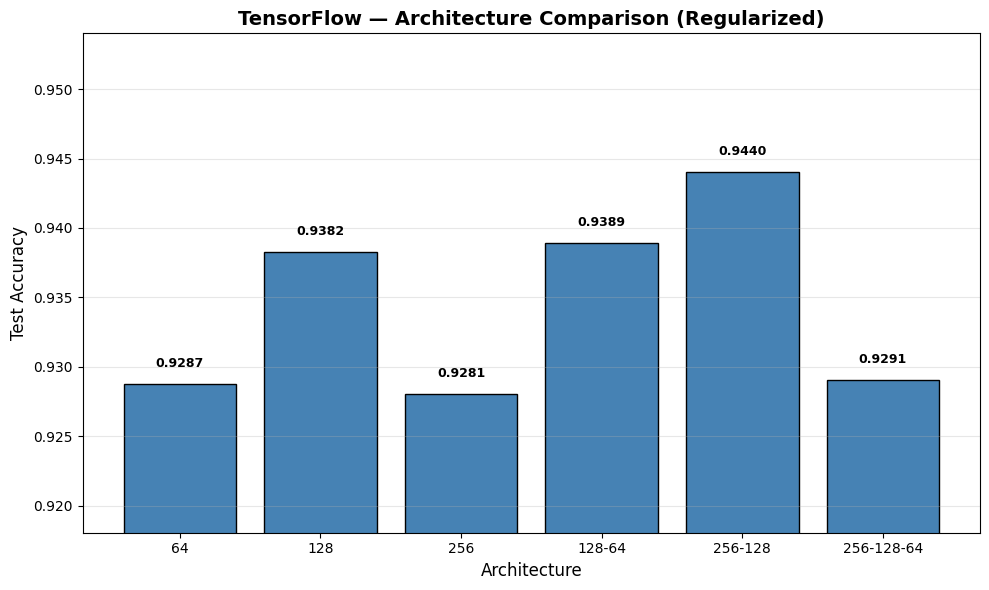


  Architecture          Acc       F1     Params   Epochs
  ----------------------------------------------------
  64                 0.9287   0.9294     36,614       26
  128                0.9382   0.9389     73,222       30
  256                0.9281   0.9273    146,438       24
  128-64             0.9389   0.9391     81,350       28
  256-128            0.9440   0.9443    179,078       28
  256-128-64         0.9291   0.9281    187,206       23

  Best: 256-128 (Acc: 0.9440)


In [5]:
# Step 5: Architecture sweep with regularization

# All architectures use BatchNorm + Dropout + Keras callbacks
print("=" * 60)
print("[5/8] ARCHITECTURE SWEEP (REGULARIZED)")
print("=" * 60)

architectures = {
    '64':           (64,),
    '128':          (128,),
    '256':          (256,),
    '128-64':       (128, 64),
    '256-128':      (256, 128),
    '256-128-64':   (256, 128, 64),
}

arch_results = {}

for name, layers in architectures.items():
    print(f"\n  Training: {name} ...")
    tf.random.set_seed(RANDOM_STATE)
    model = build_model(layers, dropout=0.3)

    h = model.fit(
        X_train, y_train, epochs=200, batch_size=BATCH_SIZE, validation_split=0.1,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20,
                                          restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                                              patience=5)
        ],
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    metrics = evaluate_classifier(y_test, y_pred)
    n_params = model.count_params()

    arch_results[name] = {
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'epochs': len(h.history['loss']),
        'n_params': n_params
    }
    print(f"    Acc: {metrics['accuracy']:.4f} | F1: {metrics['macro_f1']:.4f} | Params: {n_params:,} | Epochs: {len(h.history['loss'])}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = list(arch_results.keys())
accs = [arch_results[n]['accuracy'] for n in names]
bars = ax.bar(names, accs, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Architecture', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(f'{FRAMEWORK} — Architecture Comparison (Regularized)', fontsize=14, fontweight='bold')
ax.set_ylim(min(accs) - 0.01, max(accs) + 0.01)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/architecture_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\n  {'Architecture':<16} {'Acc':>8} {'F1':>8} {'Params':>10} {'Epochs':>8}")
print(f"  {'-'*52}")
for name in names:
    r = arch_results[name]
    print(f"  {name:<16} {r['accuracy']:>8.4f} {r['macro_f1']:>8.4f} {r['n_params']:>10,} {r['epochs']:>8}")

best_arch = max(arch_results, key=lambda k: arch_results[k]['accuracy'])
print(f"\n  Best: {best_arch} (Acc: {arch_results[best_arch]['accuracy']:.4f})")

[6/8] BEST MODEL — FULL EVALUATION

  Architecture: 561 → 128 → 64 → 6
  Epochs: 29 (best at 9)
  Training time: 9.14s

  Test Metrics:
    Accuracy: 0.9423
    Macro F1: 0.9428


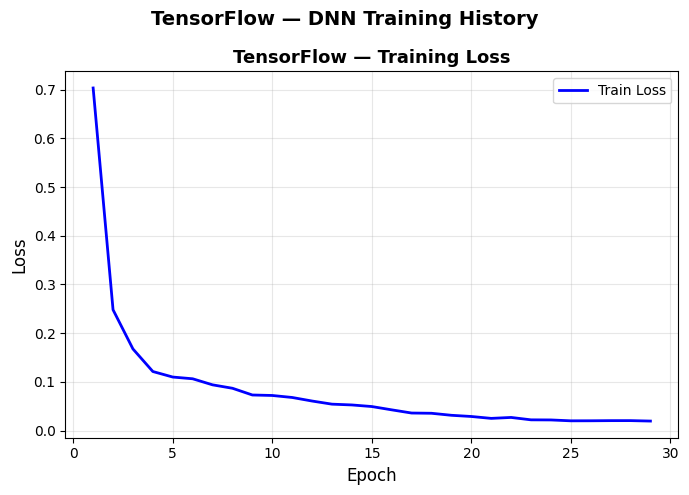

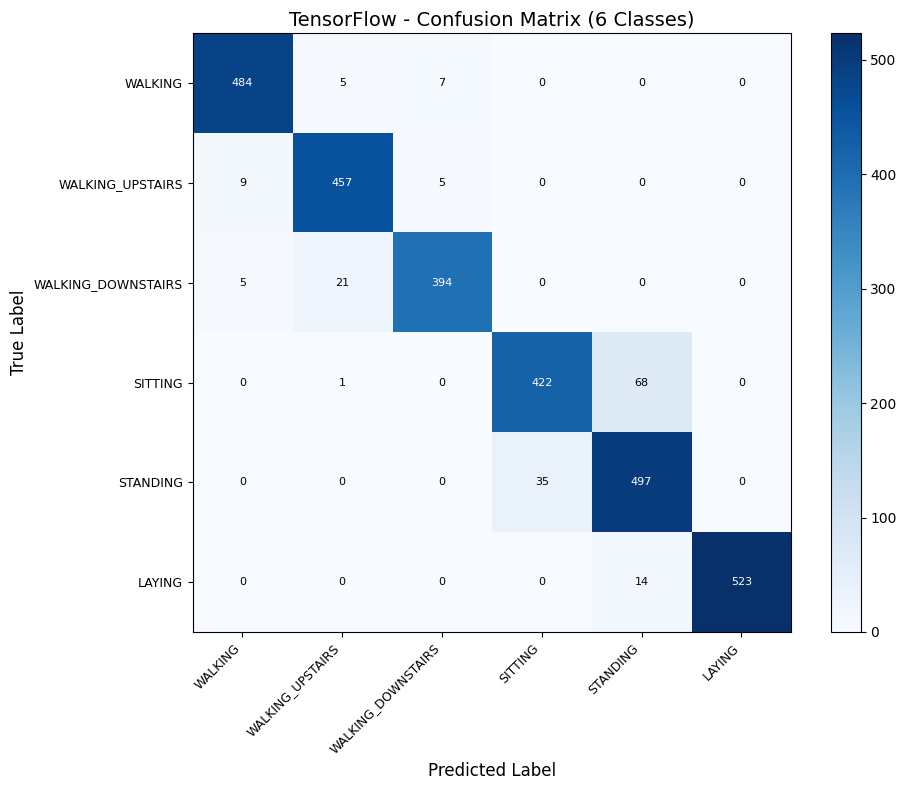

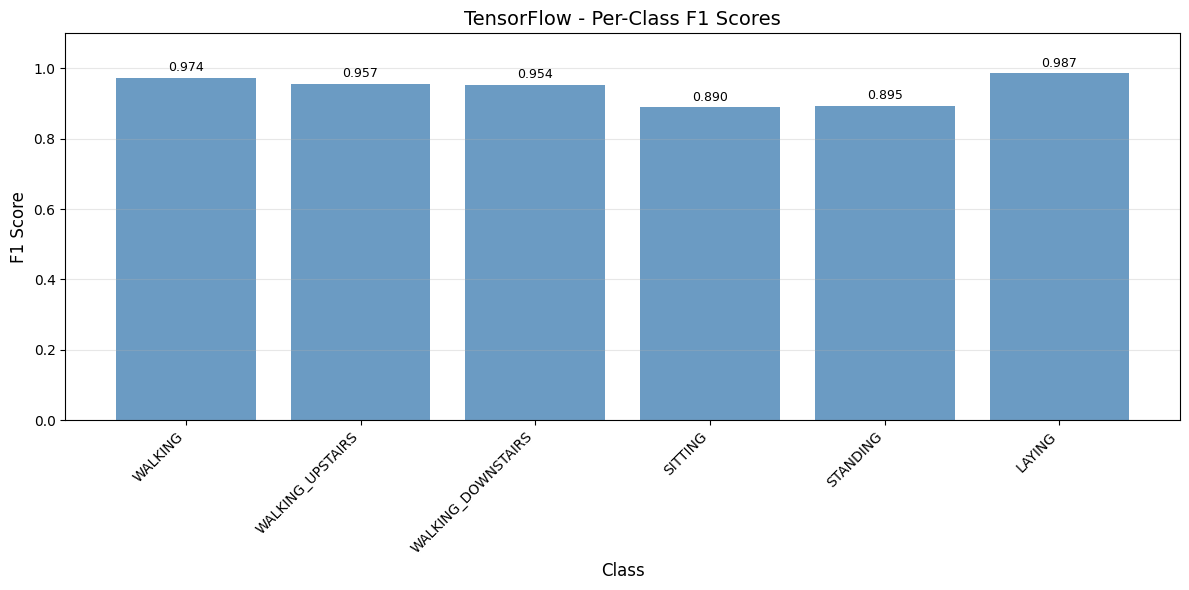

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,284 (950.33 KB)

 Trainable params: 80,966 (316.27 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 161,934 (632.56 KB)

In [6]:
# Step 6: Retrain best architecture (128-64) with full evaluation
print("=" * 60)
print("[6/8] BEST MODEL — FULL EVALUATION")
print("=" * 60)

best_model = build_model((128, 64), dropout=0.3)

with track_performance() as perf:
    h_best = best_model.fit(
        X_train, y_train, epochs=200, batch_size=BATCH_SIZE, validation_split=0.1,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20,
                                          restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                                              patience=5)
        ],
        verbose=0
    )

y_pred = best_model.predict(X_test, verbose=0).argmax(axis=1)
metrics = evaluate_classifier(y_test, y_pred)
n_params = best_model.count_params()

n_epochs = len(h_best.history['loss'])
best_val_acc = max(h_best.history['val_accuracy'])
best_epoch = h_best.history['val_accuracy'].index(best_val_acc) + 1

print(f"\n  Architecture: 561 → 128 → 64 → 6")
print(f"  Epochs: {n_epochs} (best at {best_epoch})")
print(f"  Training time: {perf['time']:.2f}s")
print(f"\n  Test Metrics:")
print(f"    Accuracy: {metrics['accuracy']:.4f}")
print(f"    Macro F1: {metrics['macro_f1']:.4f}")

# Training history
history = {
    'train_loss': h_best.history['loss'],
    'val_acc': h_best.history['val_accuracy']
}
plot_training_history(history, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_best.png')

# Confusion matrix
plot_confusion_matrix_multiclass(y_test, y_pred, ACTIVITY_NAMES, FRAMEWORK,
                                  save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# Per-class F1
plot_per_class_f1(y_test, y_pred, ACTIVITY_NAMES, FRAMEWORK,
                   save_path=f'{RESULTS_DIR}/per_class_f1.png')

# Model summary
best_model.summary()

In [7]:
# Step 7: Performance benchmarks
print("=" * 60)
print("[7/8] PERFORMANCE BENCHMARKS")
print("=" * 60)

print(f"\n  Training time: {perf['time']:.2f}s")
print(f"  Memory: {perf['memory']:.2f} MB")

# Inference benchmark
def predict_fn(X_np):
    return best_model.predict(X_np, verbose=0).argmax(axis=1)

inference_result = track_inference(predict_fn, X_test, n_runs=100)
print(f"\n  Inference ({X_test.shape[0]} samples):")
print(f"    Total: {inference_result['total_time']:.4f}s")
print(f"    Per sample: {inference_result['per_sample_us']:.2f} µs")

# Model size — from Keras trainable variables
model_bytes = sum(v.numpy().nbytes for v in best_model.trainable_variables)
model_size = model_bytes
print(f"\n  Model size: {model_size / 1024:.2f} KB")
print(f"  Parameters: {n_params:,}")
print(f"  Architecture: 561 → 128 → 64 → 6")

# Model summary
print(f"\n  Model Architecture:")
best_model.summary()

[7/8] PERFORMANCE BENCHMARKS

  Training time: 9.14s
  Memory: 19.98 MB

  Inference (2947 samples):
    Total: 0.0934s
    Per sample: 31.68 µs

  Model size: 316.27 KB
  Parameters: 81,350
  Architecture: 561 → 128 → 64 → 6

  Model Architecture:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,284 (950.33 KB)

 Trainable params: 80,966 (316.27 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 161,934 (632.56 KB)

In [8]:
# Step 8: Save results + cross-framework comparison
print("=" * 60)
print("[8/8] SAVE RESULTS")
print("=" * 60)

test_metrics = {
    'accuracy': metrics['accuracy'],
    'macro_f1': metrics['macro_f1']
}

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='DNN',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_result,
    model_size=model_size,
    architecture='561-128(BN+DO)-64(BN+DO)-6',
    n_params=n_params,
    epochs=n_epochs,
    best_epoch=best_epoch,
    activation='relu',
    dropout=0.3,
    batch_norm=True,
    lr_scheduler='ReduceLROnPlateau',
    early_stopping=True
)

save_results(results, f'{RESULTS_DIR}/dnn.json')
print(f"\n  Results saved to {RESULTS_DIR}/dnn.json")

# Add to cross-framework comparison
add_result('dnn', results)
print_comparison('dnn')

[8/8] SAVE RESULTS
    Results saved to: results/dnn.json\metrics.json

  Results saved to results/dnn.json
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\dnn.json
    Frameworks recorded: 3/4

CROSS-FRAMEWORK COMPARISON: DNN
Metric                                         Scikit-Learn                      PyTorch                   TensorFlow
---------------------------------------------------------------------------------------------------------------------
model                                                   DNN                          DNN                          DNN
training_time                                        2.42 s                      14.65 s                       9.14 s
inference_time_per_sample_us                        0.65 µs                      0.35 µs                     31.68 µs
model_size_bytes                                   314.8 KB                     696.5 KB                     316.3 KB
peak_m